# SEAMAP data 

https://seamapdata.gsmfc.org/

All data from the Southeast Area Monitoring & Assessment Program (SEAMAP)-Gulf of America program. 
This program regularlly samples in the Gulf and while we can't use the other SEAMAP data, this dataset aids in building out chlorophyll samples in the Gulf of America

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
seamap_df = pd.read_csv(r'C:\Users\gianna.milton\Documents\Python\one off cruises\SeaMAP\SEAMAPDATAV3CSV\envrec.csv')
stations_df = pd.read_csv(r'C:\Users\gianna.milton\Documents\Python\one off cruises\SeaMAP\SEAMAPDATAV3CSV\starec.csv')
#match seamap_df to stations_df for metadata retention
stations_df['START_DATE'] = pd.to_datetime(stations_df['START_DATE'], errors='coerce')
stations_df=stations_df[['STATIONID', 'CRUISEID', 'VESSEL', 'CRUISE_NO', 'P_STA_NO','START_DATE','DECSLAT','DECSLON']]
seamap_df2 = pd.merge(seamap_df, stations_df, on=['STATIONID', 'CRUISEID', 'VESSEL', 'CRUISE_NO', 'P_STA_NO'], how='left').reset_index(drop=True)
#if lat or lon in seamap are 0 or empty, replace with decslat and decslon 
seamap_df2['LATITUDE'] = seamap_df2['LATITUDE'].fillna(seamap_df2['DECSLAT'])
seamap_df2.loc[seamap_df2['LATITUDE'] == 0, 'LATITUDE'] = seamap_df2['DECSLAT']
seamap_df2['LONGITUDE'] = seamap_df2['LONGITUDE'].fillna(seamap_df2['DECSLON'])
seamap_df2.loc[seamap_df2['LONGITUDE'] == 0, 'LONGITUDE'] = seamap_df2['DECSLON']

In [ ]:
seamap_df2=seamap_df2[['CRUISEID', 'START_DATE','LATITUDE','LONGITUDE', 'STATIONID','P_STA_NO','SECCHI_DSK','DEPTH_ESRF', 'DEPTH_EMID', 'DEPTH_EMAX', 'DEPTH_EWTR', 
                       'CHLORSURF','CHLORMID', 'CHLORMAX']]
seamap_df2 = seamap_df2.rename(columns={"DEPTH_ESRF": "depth_min", "DEPTH_EMID": "depth_mid","DEPTH_EMAX":"depth_max",'DEPTH_EWTR':'water_depth',
                                         "CHLORSURF": "chl_min", "CHLORMID": "chl_mid","CHLORMAX":"chl_max",
                                         "START_DATE": "datetime",'SECCHI_DSK':'secchi_depth','LATITUDE':'lat','LONGITUDE':'lon'}).reset_index(drop=True)

SEAMAP saves the chlorophyll samples in 3 distinct columns: chl_min, chl_mid, and chl_max.

![SEAMAP_bottle](images/seamap_stackedCHL.png)

So the SEAMAP columns need to be standardized into a single depth column and a single chlorophyll column

In [ ]:
seamap_df2['row_id'] = seamap_df2.index
stubs = ['depth', 'chl']
#turn into dataframe with 1 depth, 1 temp, ect, with i = the columns that stay constant
seamap_df3 = pd.wide_to_long(seamap_df2,stubnames=stubs, i=['row_id','CRUISEID', 'datetime', 'lat', 'lon', 'P_STA_NO','STATIONID','secchi_depth','water_depth'], 
    j='level', sep='_',   suffix='\w+')
seamap_df3 = seamap_df3.reset_index()
seamap_df3 = seamap_df3.drop(columns=['row_id'])
seamap_df3 = seamap_df3.dropna(subset=['chl'], how='all')


In [ ]:
seamap_df3.rename(columns={"CRUISEID": "cruise", "P_STA_NO": "station", "date": "datetime", "Chl-a_µg/L": "chl_a"}, inplace=True)

seamap_df3['source'] = 'SEAMAP'
seamap_df3['DOI_url'] = 'https://seamapdata.gsmfc.org/seamap.download.php'
seamap_df3['experiment'] = 'SEAMAP'
seamap_df3['investigators'] = 'Jeff Rester'
seamap_df3['affiliations'] = 'GSMFC'

seamap_df3['HPLC'] = 1
counts_series = seamap_df3[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
seamap_df3['triplicate'] = 1 #based on inpsecting counts_series, no triplicates


In [ ]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(seamap_df3, geometry=gpd.points_from_xy(seamap_df3.lon, seamap_df3.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
seamap_df3 = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id', 'STATIONID', 'level','water_depth','secchi_depth']
seamap_df3 = seamap_df3.drop(columns=columns_to_drop)
seamap_df3 = seamap_df3[seamap_df3['datetime'] > '2000-01-01']
seamap_df3= seamap_df3.reset_index(drop=True)

Seamap data complete! 

# Plots

In [2]:
seamap = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\seamap_chl.xlsx')

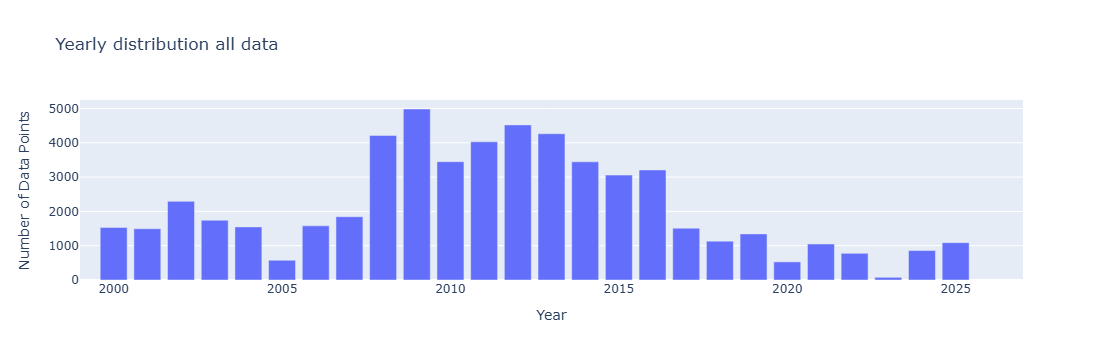

In [3]:
year_test=seamap.copy()
year_test['date'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['date'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


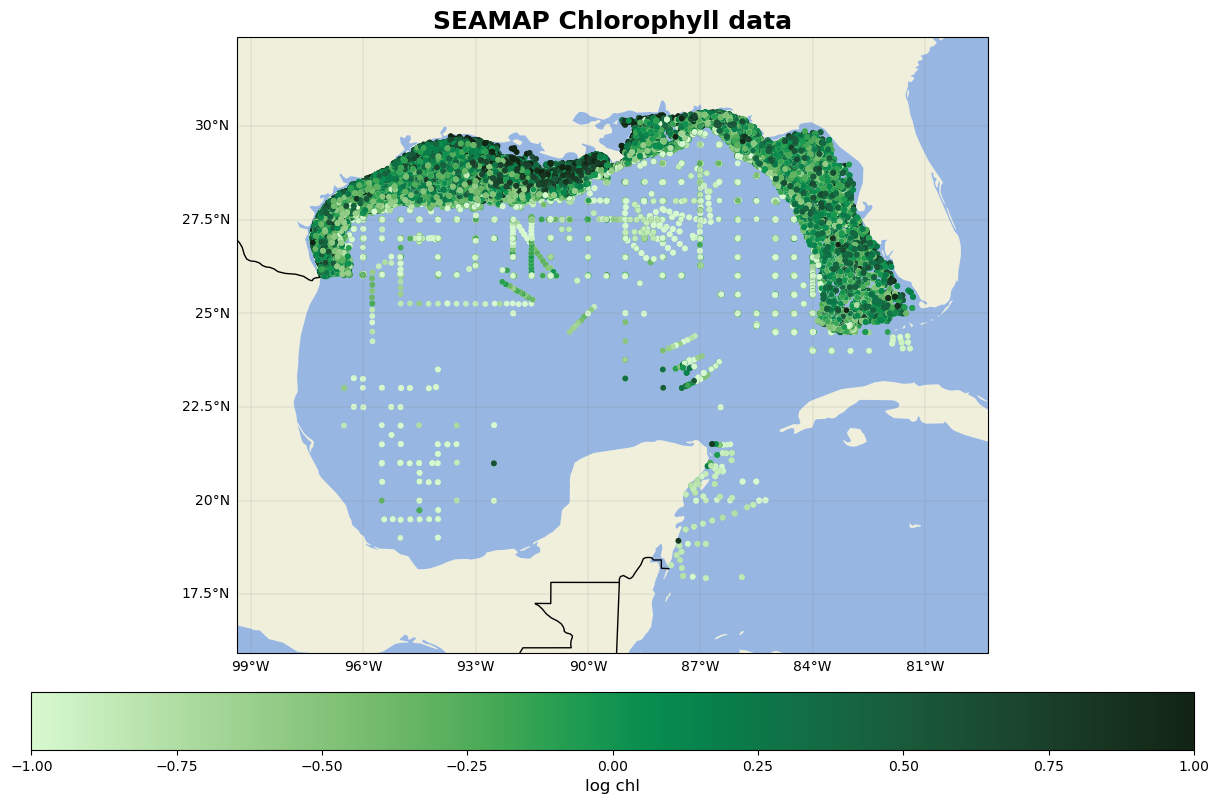

In [6]:
year_test['log_chl']=np.log10(year_test['chl'])

fig=plt.figure(figsize=(15, 10))
axs1=fig.add_subplot(1,1,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs1.set_title('SEAMAP Chlorophyll data', fontsize=18, fontweight='bold')
axs1.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
axs1.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal', pad=0.05)
cb.set_label('log chl',fontsize=12)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels


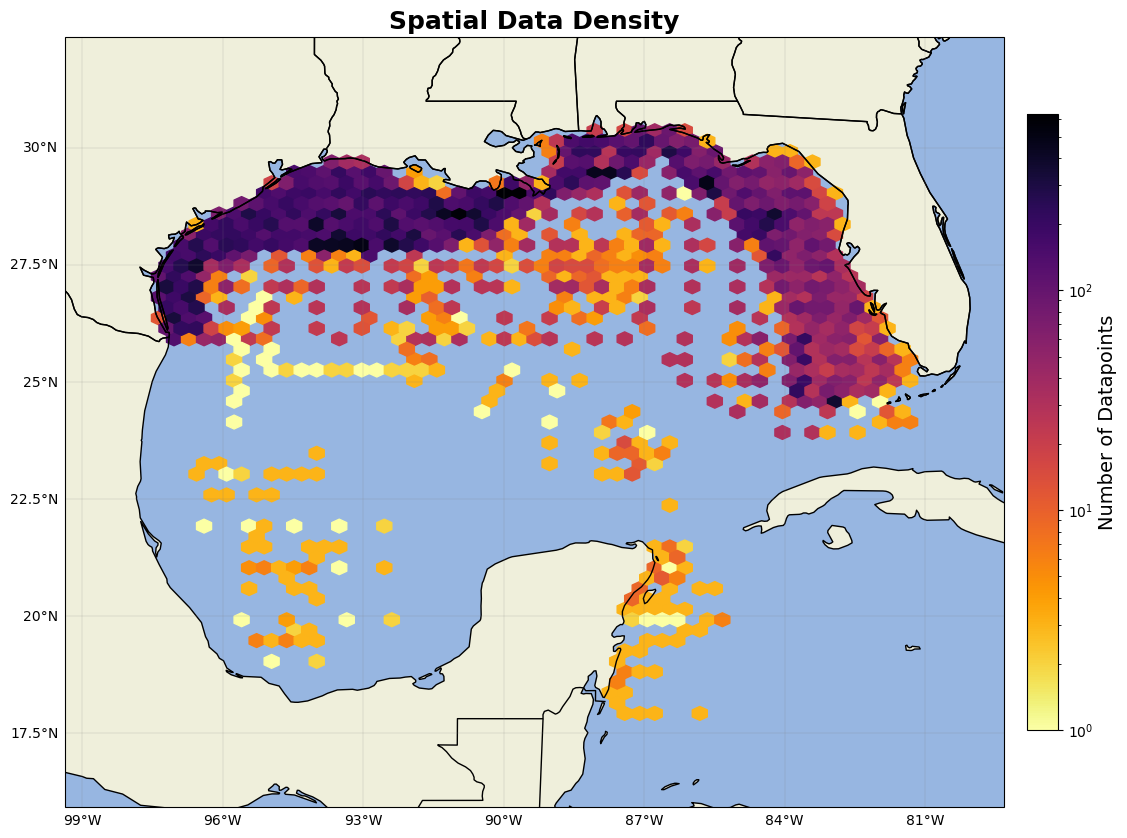

In [5]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=50, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()